In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import math

In [5]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

### Problem Set Guidelines:


#### **ASSIGNED:**  January 16, 2026

#### **DUE:**  Friday, January 23, 2026 at 9:00 pm submitted on Canvas.  Problem sets more than 24 hr late will not be accepted.

1. Each solution must be your own work.
2. All problems that involve python must be completed in Jupyter Notebooks.  Some problems may not require python and may be better completed with pen and paper.  
3. Highlight your final answer when providing numerical results.  Provide plots, graphs, and tables of your results when appropriate.
4. **Submission Instructions:**  This quarter we will use Canvas to collect your submissions and grade them.  We ask that you submit **both** your Jupyter Notebook file and a single PDF with your compiled solutions.  Please follow the instructions below to obtain a PDF file from a Jupyter Notebook:
    - Make sure all your code runs without error, and all figures (if any) show up where intended.  We will not be running your code, therefore it is essential that your solutions output and highlight your results.  Please be mindful of your line length so that it fits into the PDF layout and your results are clearly shown.
    - Select File->Download as->HTML (.html).  This will download an HTML version your_homework.html of your notebook to your computer, typically in your Download folder.
    - Open your_homework.html in your web browser (just double-click on it).  Use the File->Print command of your browser to produce a PDF file.  (Do not produce the PDF in other ways, such as “Export to PDF” or other.  Alternative methods will usually produce poor page margins, format headers differently, fail to incorporate figures, and so forth.)
    - Submit your PDF file your_homework.pdf to Canvas.  Do not submit your HTML file.  
5. Note that you can wrap lines of python code **using the “\” operator** to ensure that all your code is visible within the width of the PDF page.  Please do so wherever appropriate.

### Problem 1 - Finite Differences, More Like Fun-ite Differences

(a)  This can be done in Latex inside of your Jupyter Notebook or written out (by hand or virtually). If you write out your derivation, please add a screenshot/image of your work to a Markdown cell in this notebook. This can be done by copying the image and simply pasting it into a Markdown cell.

- Compute the analytical first derivative of $f(x) = \frac{-7\cos(x)}{x}+\ln(x)$.

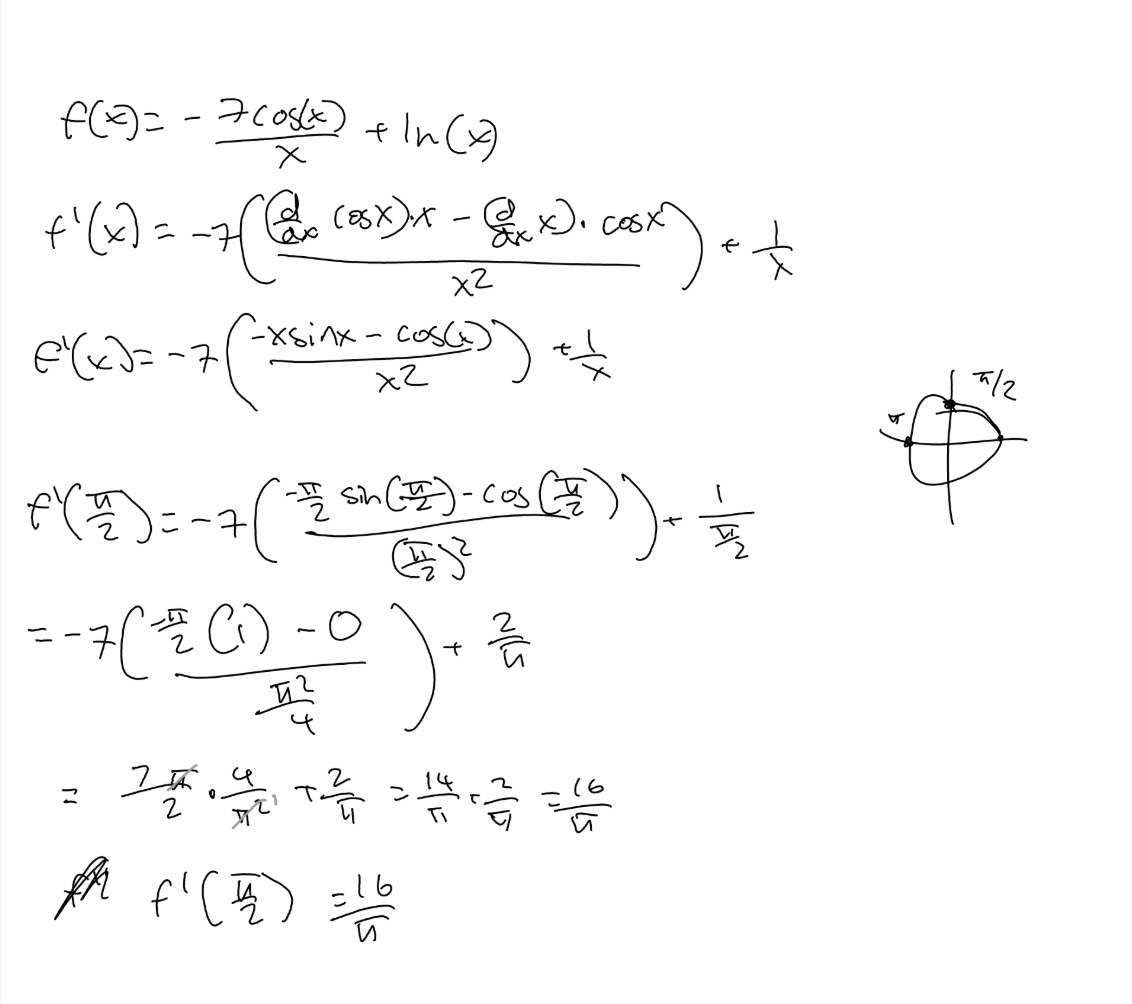

- Compute the value of $f'(x)$ at $x=\frac{\pi}{2}$.

SEE ABOVE MARKDOWN CELL


 (b) This can be done in Latex inside of your Jupyter Notebook or written out (by hand or virtually). If you write out your derivation, please add a screenshot/image of your work to a Markdown cell in this notebook. This can be done by copying the image and simply pasting it into a Markdown cell.
- Derive the formula for the second order (note: this does not mean second derivative) forward finite-difference approximation (FFD) for $f'(x_i)$. This is also sometimes called the three-point forward finite-difference approximation. (***Hint 1:** Start by writing out a third order Taylor expansion for $f(x_{i+1})$ and $f(x_{i+2})$. Since it is the second order FFD, your final expression for $f'(x_i)$ should be in terms of $f(x_i)$, $f(x_{i+1})$, $f(x_{i+2})$, and $\Delta x$ (which is equivalent to $x_{i+1}-x_i$). **Hint 2:** How can you combine these two Taylor expansions to eliminate $f''(x_i)$?* )

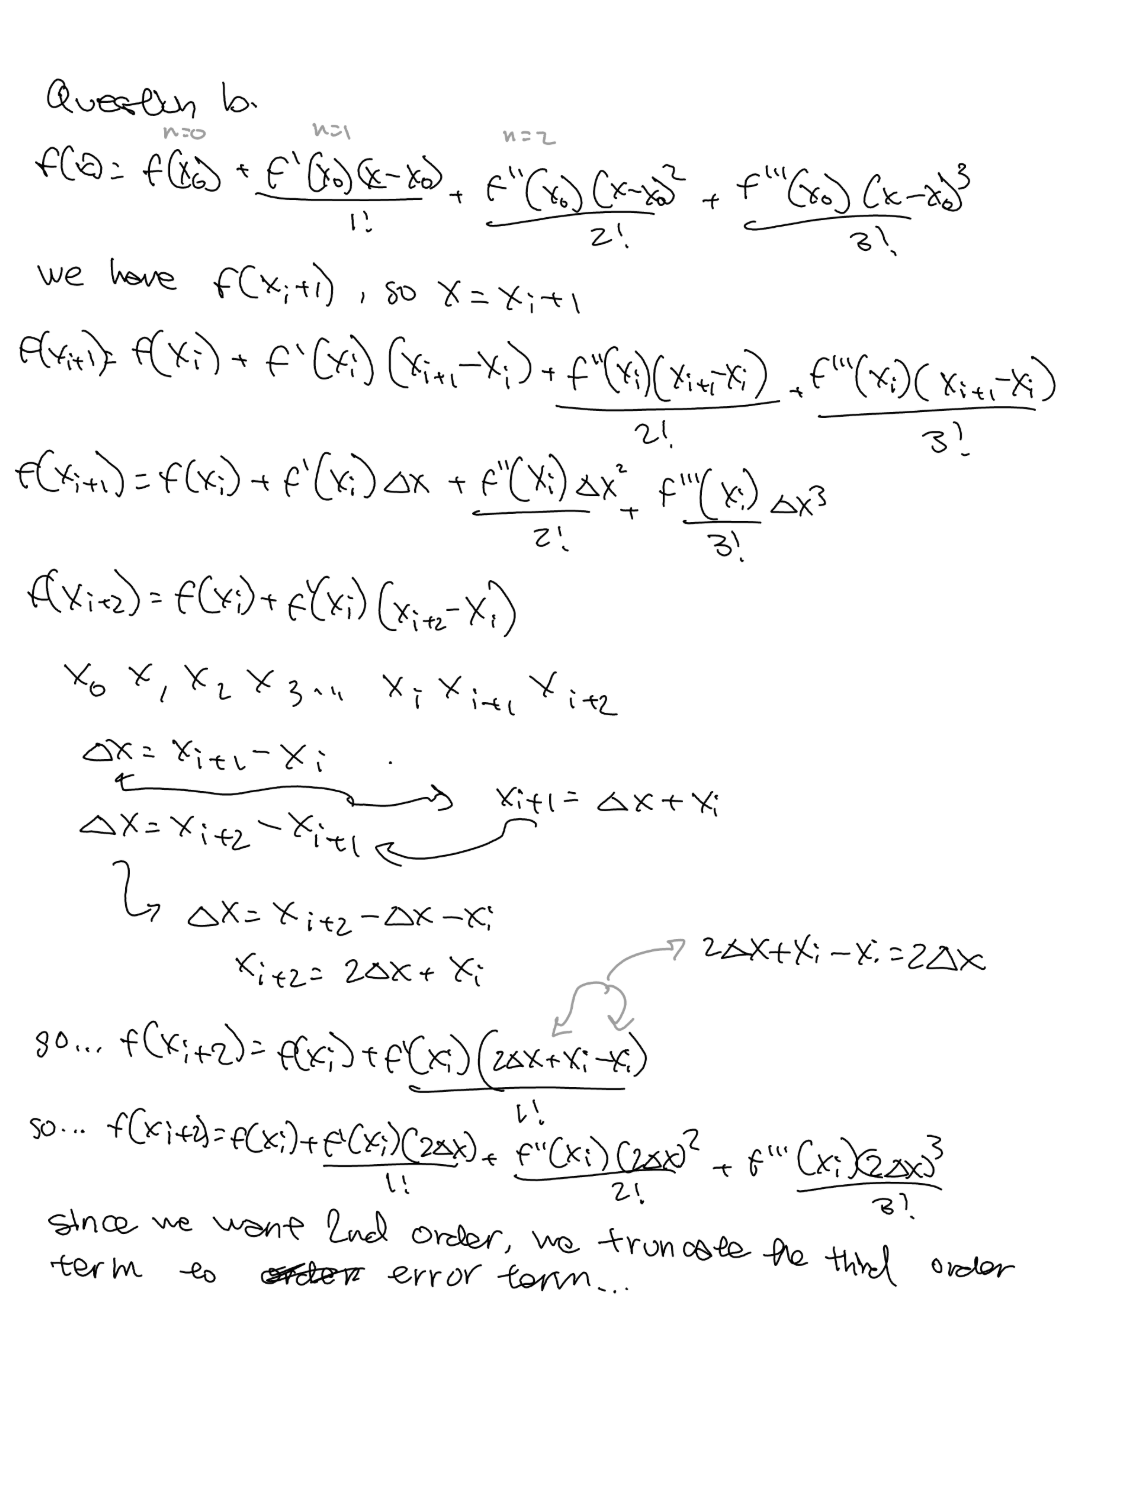

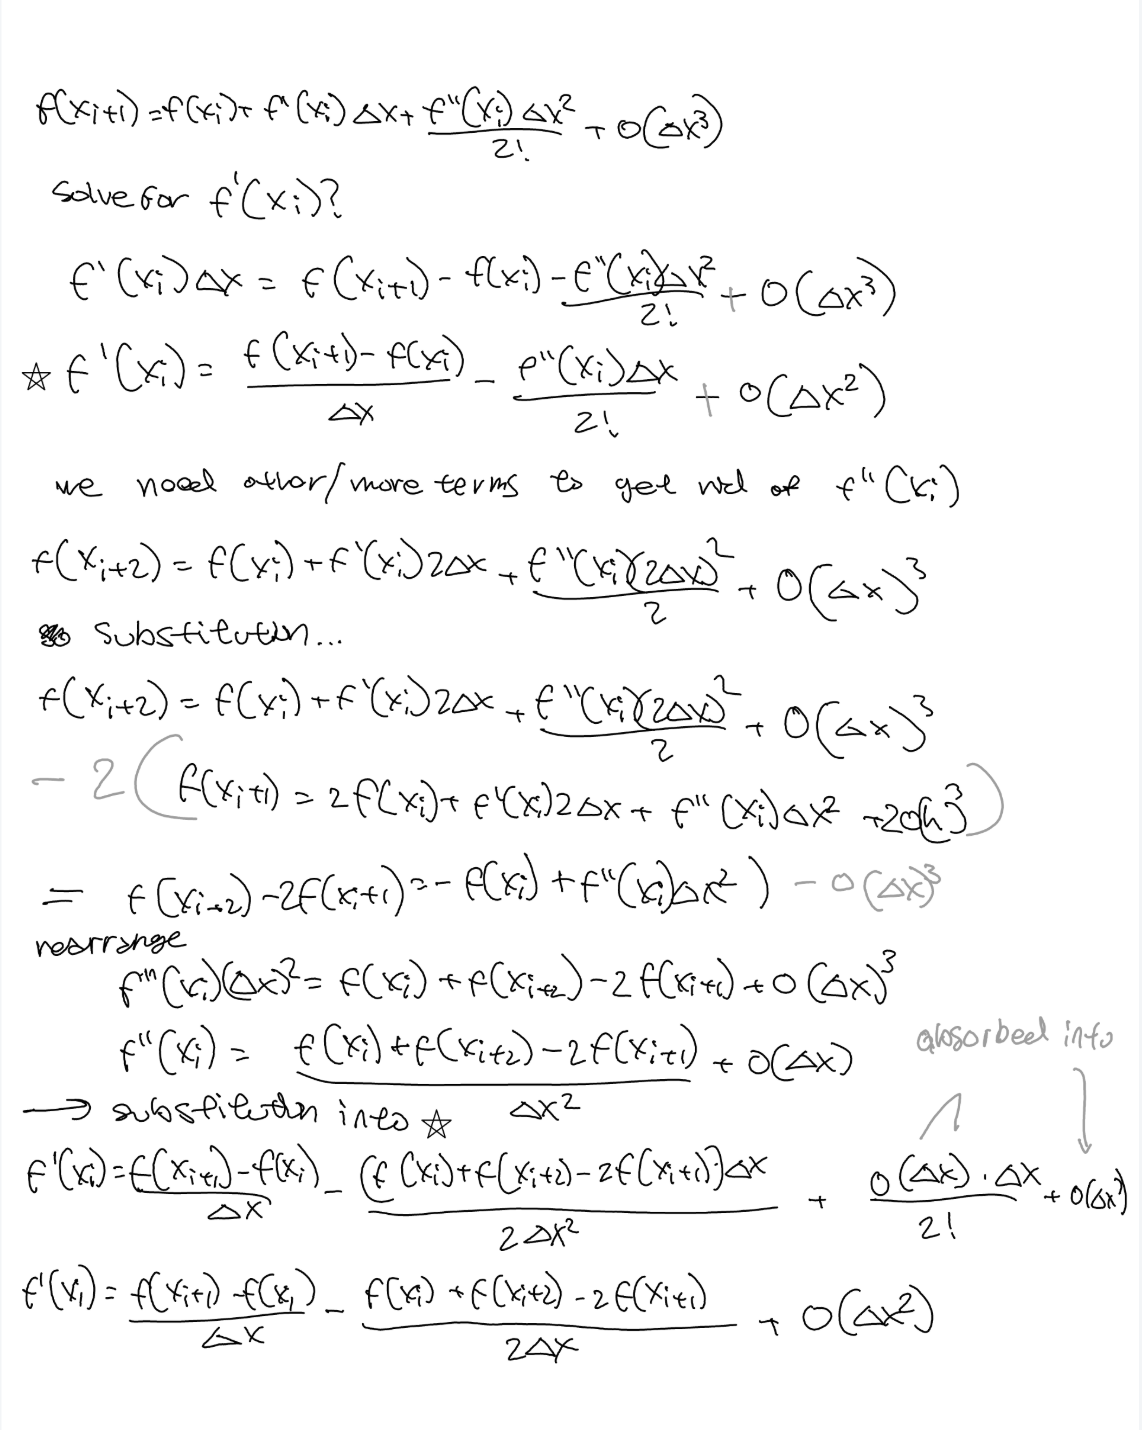

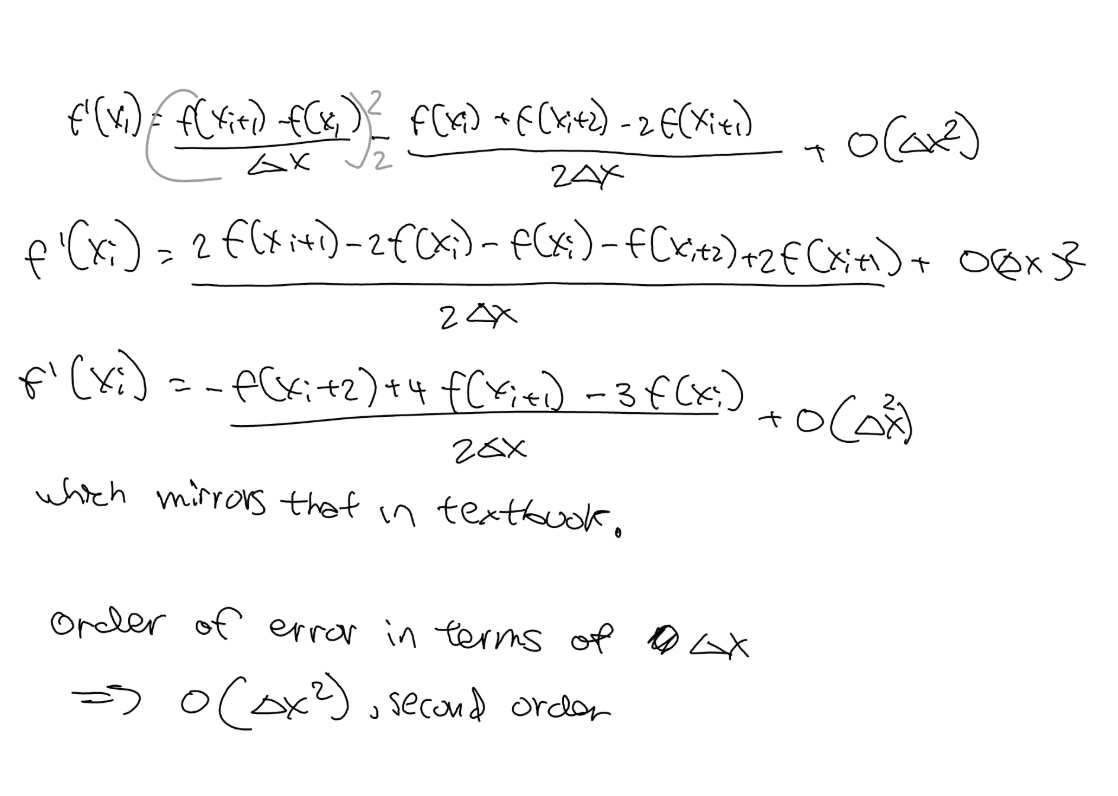

- What is the order of the error term in terms of $\Delta x$?

SEE ABOVE PHOTOS

(c)
- Write functions for $f(x)$ and $f'(x)$.

In [6]:
def f(x):
    
    return ((-7*np.cos(x)) / x) + np.log(x)

#testing function
f(np.pi/2)
#correct

0.45158270528945454

In [7]:
def f_prime(x):
    return (-7*((-x*np.sin(x) - np.cos(x)) / (x**2))) + 1/x

#testing function
f_prime(np.pi/2)
#correct

5.092958178940651

- Write a function/functions the first- and second-order (a.k.a two point and three point) **central** finite-difference (CFD) approximations for the first derivative of $f(x)$. (*Hint 1: You are not expected to derive the second order CFD approximation yourself. See p. 657 of Numerical Methods for Engineers, 7ed.*)

In [8]:
def sec_order_CFD(f,x,h):
    return (f(x+h) - f(x-h)) / (2*h)

def fourth_order_CFD(f,x,h):
    return (-f(x+(2*h)) + 8*f(x+h) - 8*f(x-h) + f(x-(2*h))) / (12*h)



In [9]:
import numpy as np

def approx_point_deriv(f, x, h, deriv=1, method='central', order='low'):
    """
    Approximates derivative at point x.
    Returns: (float_value, [list_containing_value])
    """
    slope_appxs = []
    slope = 0.0

    # --- FIRST DERIVATIVE (f') ---
    if deriv == 1:
        if method == 'forward':
            if order == 'low':  # O(h)
                slope = (f(x + h) - f(x)) / h
            else:               # O(h^2)
                slope = (-f(x + 2*h) + 4*f(x + h) - 3*f(x)) / (2*h)
        elif method == 'backward':
            if order == 'low':  # O(h)
                slope = (f(x) - f(x - h)) / h
            else:               # O(h^2)
                slope = (3*f(x) - 4*f(x - h) + f(x - 2*h)) / (2*h)
        elif method == 'central':
            if order == 'low':  # O(h^2)
                slope = (f(x + h) - f(x - h)) / (2*h)
            else:               # O(h^4)
                slope = (-f(x + 2*h) + 8*f(x + h) - 8*f(x - h) + f(x - 2*h)) / (12*h)

    # --- SECOND DERIVATIVE (f'') ---
    elif deriv == 2:
        if method == 'forward':
            if order == 'low':  # O(h)
                slope = (f(x + 2*h) - 2*f(x + h) + f(x)) / (h**2)
            else:               # O(h^2)
                slope = (-f(x + 3*h) + 4*f(x + 2*h) - 5*f(x + h) + 2*f(x)) / (h**2)
        elif method == 'backward':
            if order == 'low':  # O(h)
                slope = (f(x) - 2*f(x - h) + f(x - 2*h)) / (h**2)
            else:               # O(h^2)
                slope = (2*f(x) - 5*f(x - h) + 4*f(x - 2*h) - f(x - 3*h)) / (h**2)
        elif method == 'central':
            if order == 'low':  # O(h^2)
                slope = (f(x + h) - 2*f(x) + f(x - h)) / (h**2)
            else:               # O(h^4)
                slope = (-f(x + 2*h) + 16*f(x + h) - 30*f(x) + 16*f(x - h) - f(x - 2*h)) / (12*h**2)

    slope_appxs.append(slope)
    return slope, slope_appxs

- Evaluate both central finite-difference approximations for $f'(\pi /2)$ for a range of $\Delta x \in [0.01, 0.5]$. Plot both approximations as a function of $\Delta x$ on one plot. Include a horizontal line at the true value of $f'(x)$ you computed in part (a).

(array([5.09307312, 5.09321507, 5.09341337, 5.09366804, 5.09397911,
       5.09434662, 5.09477062, 5.09525116, 5.09578831, 5.09638212,
       5.09703267, 5.09774005, 5.09850434, 5.09932564, 5.10020405,
       5.10113969, 5.10213267, 5.10318311, 5.10429116, 5.10545694,
       5.10668061, 5.10796232, 5.10930224, 5.11070053, 5.11215737,
       5.11367295, 5.11524747, 5.11688111, 5.1185741 , 5.12032664,
       5.12213897, 5.12401132, 5.12594393, 5.12793704, 5.12999092,
       5.13210582, 5.13428204, 5.13651984, 5.13881953, 5.1411814 ,
       5.14360575, 5.14609292, 5.14864322, 5.151257  , 5.15393459,
       5.15667636, 5.15948267, 5.16235389, 5.1652904 , 5.1682926 ,
       5.1713609 , 5.1744957 , 5.17769743, 5.18096653, 5.18430343,
       5.1877086 , 5.1911825 , 5.19472561, 5.19833841, 5.20202141,
       5.20577511, 5.20960004, 5.21349673, 5.21746573, 5.2215076 ,
       5.22562291, 5.22981224, 5.23407618, 5.23841535, 5.24283037,
       5.24732187, 5.25189051, 5.25653695, 5.26126186, 5.2660

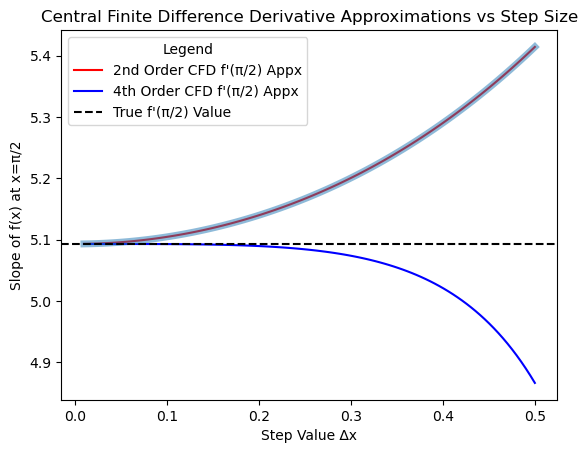

In [21]:
#stepx = range(0.01,0.5,1)

stepx = np.linspace(0.01,0.5,100, endpoint=True)


def appx(appx_func,og_function,x, step_range):
    slope_appxs=[]
    for step in step_range:
        slope_appx = appx_func(og_function,x,step)
        slope_appxs.append(slope_appx)
    return slope_appxs

sec_order_appx = appx(sec_order_CFD,f,(np.pi/2), stepx)
fourth_order_appx = appx(fourth_order_CFD,f,(np.pi/2), stepx)

second = approx_point_deriv(f,(np.pi/2),stepx,deriv=1, method = 'central', order = 'low')
print(second)
plt.plot(stepx,sec_order_appx,label = "2nd Order CFD f'(π/2) Appx", c="red")
plt.plot(stepx,fourth_order_appx, label = "4th Order CFD f'(π/2) Appx", c="blue")
plt.plot(stepx,second[0],lw=5,alpha=0.5)
plt.axhline(y=(16/np.pi),label = "True f'(π/2) Value", c="black",linestyle="--")
plt.legend(title="Legend")
plt.xlabel("Step Value ∆x")
plt.ylabel("Slope of f(x) at x=π/2")
plt.title("Central Finite Difference Derivative Approximations vs Step Size")
plt.show()


- Write a function/functions for the **forward** and **backward** finite-difference methods. In a **single figure with two subplots**, plot the approximations for $f'(\pi /2)$ from the three first-order methods (first subplot) and the three second-order methods over the same range of $\Delta x \in [0.01, 0.5]$. Again, include a horizontal line with the true value of $f'(x)$.

In [7]:
#FIRST ORDER BACKWRAD FINIITE DIFFERENCE
def first_order_BFD(f,x,h):
    return (f(x) - f(x-h)) / h

#SECOND ORDER BACKWARDS FINITE DIFFERENCE
def sec_order_BFD(f,x,h):
    g = (3*f(x) - 4*f(x-h) + f(x-(2*h))) / (2*h)
    return g

#FIRST ORDER FORWARD FINITE DIFFERENCE
def first_order_FFD(f,x,h):
    g= (f(x+h) - f(x)) / h
    return g

#SECOND ORDER FORWARD FINITE DIFFERENCE
def sec_order_FFD(f,x,h):
    g = (-f(x+(2*h)) + 4*(f(x+h)) - 3*f(x)) / (2*h)
    return g

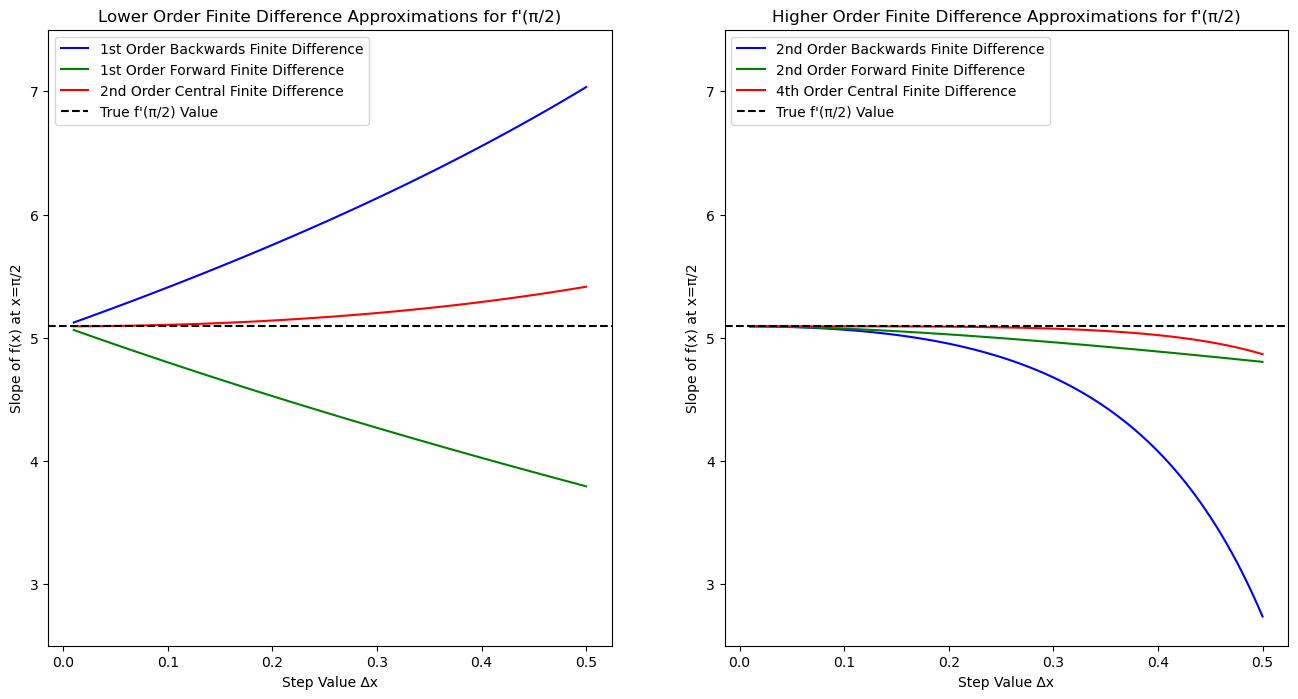

In [8]:

plt.figure(figsize=(16,8))
plt.subplot(121)
plt.title("Lower Order Finite Difference Approximations for f'(π/2)")
plt.plot(stepx,appx(first_order_BFD,f,(np.pi/2), stepx),\
label = "1st Order Backwards Finite Difference",c="blue")
plt.plot(stepx,appx(first_order_FFD,f,(np.pi/2), stepx),\
label = "1st Order Forward Finite Difference",c="green")
plt.plot(stepx,appx(sec_order_CFD,f,(np.pi/2), stepx),\
label = "2nd Order Central Finite Difference", c="red")
plt.axhline(y=(16/np.pi),label = "True f'(π/2) Value", c="black",linestyle="--")
plt.legend()
plt.ylim(2.5,7.5)
plt.xlabel("Step Value ∆x")
plt.ylabel("Slope of f(x) at x=π/2")
plt.subplot(122)
plt.title("Higher Order Finite Difference Approximations for f'(π/2)")
plt.plot(stepx,appx(sec_order_BFD,f,(np.pi/2), stepx),\
label = "2nd Order Backwards Finite Difference",c="blue")
plt.plot(stepx,appx(sec_order_FFD,f,(np.pi/2), stepx),\
label = "2nd Order Forward Finite Difference",c='green')

plt.plot(stepx,appx(fourth_order_CFD,f,(np.pi/2), stepx), \
label = "4th Order Central Finite Difference", c="red")
plt.axhline(y=(16/np.pi),label = "True f'(π/2) Value", c="black",linestyle="--")
plt.xlabel("Step Value ∆x")
plt.ylabel("Slope of f(x) at x=π/2")
#plt.ylim()

plt.ylim(2.5,7.5)
plt.legend(loc="upper left")
plt.show()


- Compare and discuss what you observe.

Relative to the true value of 5.0930, we can see that the second order derivative approxmiations are stronger. At lower step levels, they are able to say parralel to true value for a longer range of step values than the first order approxmiations are. This is because their error is a higher order than the first order, meaning that there is much less deviation from the true value, which can be observed here.

On average, it seems like the center method is better, which makes sense because it has the highest error order (4) compared to the forward and backwards methods (2). 

All methods seem to diverge at higher step values, which makes sense. 


- You may have noticed that the second order approximations converge much faster than their first order approximations, with the notable outlier of the second order BFD approximation at larger step sizes (feel free to plot the first and second order BFD on plot to verify this for yourself). Additionally, the BFD approximation have both performed the worst. What is the reason behind this deviation? (*Hint: It is always good to have an understanding of the behavior of your functions... you might want to take a peek at f(x) and f'(x).*)

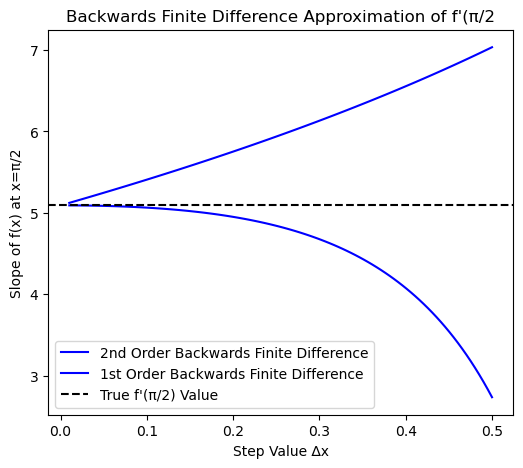

In [9]:
plt.figure(figsize=(6,5))
plt.plot(stepx,appx(sec_order_BFD,f,(np.pi/2), stepx),\
label = "2nd Order Backwards Finite Difference",c="blue")
plt.plot(stepx,appx(first_order_BFD,f,(np.pi/2), stepx),\
label = "1st Order Backwards Finite Difference",c="blue")
plt.axhline(y=(16/np.pi),label = "True f'(π/2) Value", c="black",linestyle="--")
plt.legend()
plt.xlabel("Step Value ∆x")
plt.title("Backwards Finite Difference Approximation of f'(π/2")
plt.ylabel("Slope of f(x) at x=π/2")
plt.show()




Looking at the actual f(x) and f'(x) graphs, we can see that as x approaches zero, the respective positive and negative slopes of f(x) and f'(x) increase very rapidly from -infinity and infinity. Since the backwards finite difference looks at the previous point, this "previous" point could be one that is "affected" by the vertical asymptote. The backwards method is more affected by these trends because it continuously references previous points closer to x=0. As step size increases, then the previous point is also closer to zero instead of being further away, meaning approximate slopes will be heavily skewed, which is why the BFD method is overall worse. 

- Finally, on a single plot, plot the approximations for $f'(\pi /2)$ from the **second order** central finite-difference method alongside the **second order** forward and backward finite-difference methods. Compare and discuss what you observe.

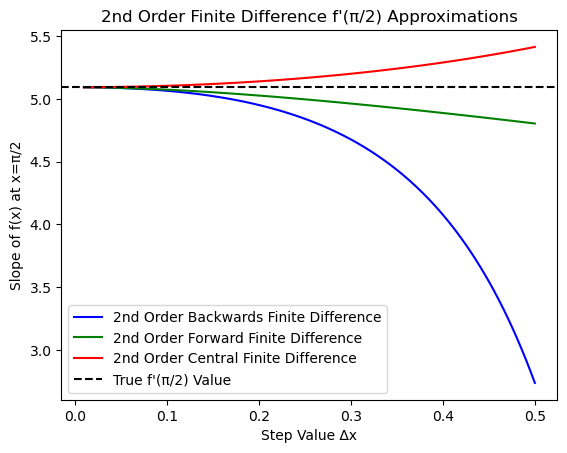

In [10]:
#I'm going to assume that second order central finite difference
#refers to the actual second order CFD, and not the fourth order, 
#which is confusing because of the spelling errors before

sec_order_appx = appx(sec_order_CFD,f,(np.pi/2), stepx)
plt.plot(stepx,appx(sec_order_BFD,f,(np.pi/2), stepx),\
label = "2nd Order Backwards Finite Difference",c="blue")
plt.plot(stepx,appx(sec_order_FFD,f,(np.pi/2), stepx),\
label = "2nd Order Forward Finite Difference",c='green')
plt.plot(stepx, appx(sec_order_CFD,f,(np.pi/2), stepx),\
label = "2nd Order Central Finite Difference", c='red')
plt.axhline(y=(16/np.pi),label = "True f'(π/2) Value", c="black",linestyle="--")
plt.xlabel("Step Value ∆x")
plt.ylabel("Slope of f(x) at x=π/2")
plt.title("2nd Order Finite Difference f'(π/2) Approximations")
plt.legend()
plt.show()


We can see similar trends observed before in the subplots. We see that the backwards finite difference dramatically diverges at a faster rate than the central and forwards finite differences. We also see that central and forward have very similar rates of convergence/divergence, as they are both second order. This shows that the methods are pretty similar to each other (given that they're of the same order). 


(d)  
- In a **single figure with two subplots**, plot the **true absolute** (first subplot) and **true relative** (second subplot) error for the approximations for $f'(\pi /2)$ from each of the finite difference methods implemented above over the same range of $\Delta x \in [0.01, 0.5]$. Both subplots should have log-log axes.

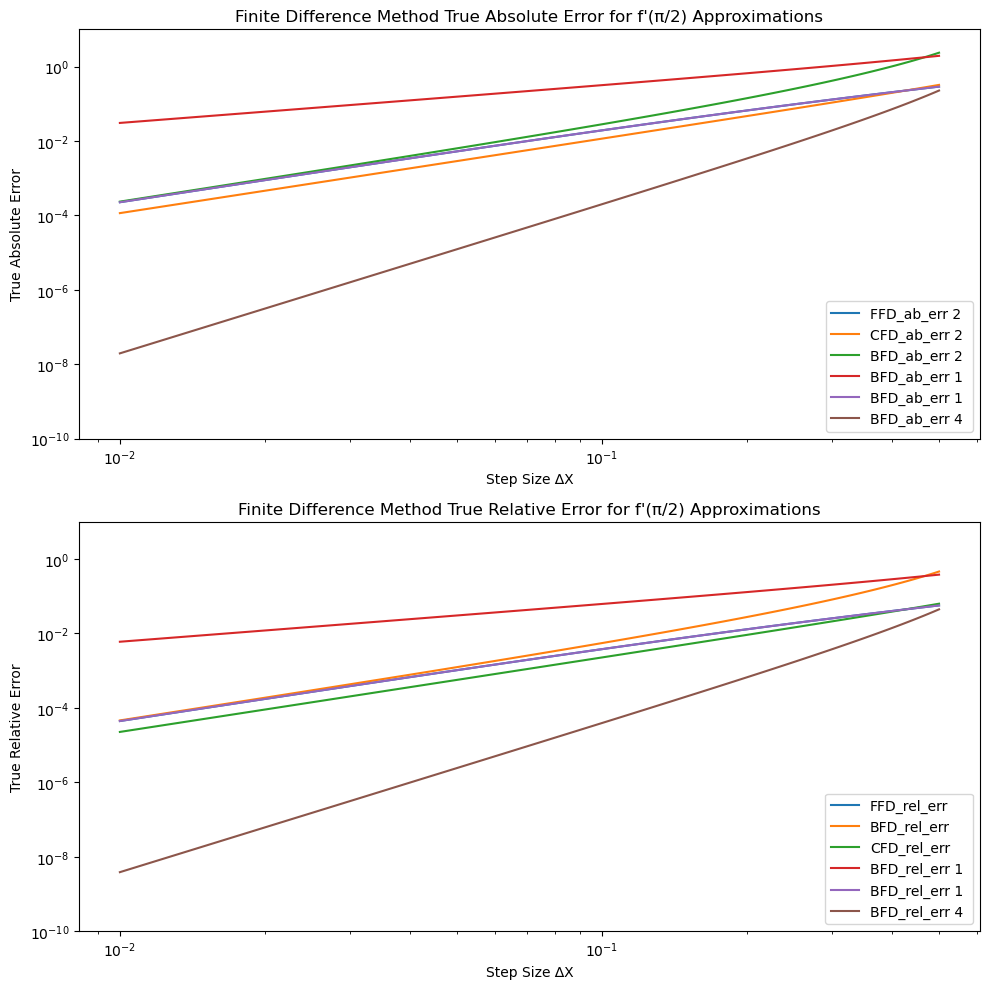

In [11]:
#true value was calculated in a previous handwritten step. 

#absolute and relative error calculations
def true_ab_err(list):
    true = 16 / np.pi
    TA_err = []
    for i in range(len(list)):
        err = np.abs(true - list[i])
        TA_err.append(err)
    return TA_err

def true_rel_err(ab_err):
    true = 16 / np.pi
    TR = []          
    for i in range(len(ab_err)):
        rel_err = ab_err[i] / true
        TR.append(rel_err)
    return(TR)

#absolute err
CFD_ab_err_2 = true_ab_err(appx(sec_order_CFD,f,(np.pi/2), stepx))
FFD_ab_err_2 = true_ab_err(appx(sec_order_FFD,f,(np.pi/2), stepx))
BFD_ab_err_2 = true_ab_err(appx(sec_order_BFD,f,(np.pi/2), stepx))

CFD_ab_err_4 = true_ab_err(appx(fourth_order_CFD,f,(np.pi/2), stepx))
FFD_ab_err_1 = true_ab_err(appx(first_order_FFD,f,(np.pi/2), stepx))
BFD_ab_err_1 = true_ab_err(appx(first_order_BFD,f,(np.pi/2), stepx))

#absolute relative error 
CFD_rel_err_2 = true_rel_err(CFD_ab_err_2)
FFD_rel_err_2 = true_rel_err(FFD_ab_err_2)
BFD_rel_err_2 = true_rel_err(BFD_ab_err_2)

BFD_rel_err_1 = true_rel_err(BFD_ab_err_1)
FFD_rel_err_1 = true_rel_err(FFD_ab_err_1)
CFD_rel_err_4 = true_rel_err(CFD_ab_err_4)


plt.figure(figsize=(10,10))


plt.subplot(211)
plt.loglog(stepx,FFD_ab_err_2,label = "FFD_ab_err 2")
plt.loglog(stepx,CFD_ab_err_2,label = "CFD_ab_err 2")
plt.loglog(stepx,BFD_ab_err_2,label = "BFD_ab_err 2")
plt.loglog(stepx,BFD_ab_err_1,label = "BFD_ab_err 1 ")
plt.loglog(stepx,FFD_ab_err_2,label = "BFD_ab_err 1 ")
plt.loglog(stepx,CFD_ab_err_4,label = "BFD_ab_err 4")
plt.xlabel("Step Size ∆X")

plt.title("Finite Difference Method True Absolute Error for f'(π/2) Approximations")
plt.ylabel("True Absolute Error")
plt.legend()
plt.ylim(1e-10,1e1)


plt.subplot(212)
plt.loglog(stepx,FFD_rel_err_2,label = "FFD_rel_err")
plt.loglog(stepx,BFD_rel_err_2,label = "BFD_rel_err")
plt.loglog(stepx,CFD_rel_err_2,label = "CFD_rel_err")
plt.loglog(stepx,BFD_rel_err_1,label = "BFD_rel_err 1 ")
plt.loglog(stepx,FFD_rel_err_2,label = "BFD_rel_err 1 ")
plt.loglog(stepx,CFD_rel_err_4,label = "BFD_rel_err 4")
plt.title("Finite Difference Method True Relative Error for f'(π/2) Approximations")
plt.xlabel("Step Size ∆X")
plt.ylabel("True Relative Error")
plt.legend()
plt.ylim(1e-10,1e1)
plt.tight_layout()
plt.show()




- What is the scaling behavior of the error with respect to $\Delta x$ for each approximation (i.e., both first and second order approximation for the forward, backward, and central finite-difference methods)? Perform a linear regression on either error (true absolute or relative) to verify your intuition. Use `scipy.stats.linregress` to perform these regressions, printing the slope for each finite difference approximation to **two significant figures**. You will program your own linear regression function in the next problem, but it is good to get familiar with the scipy library/ reading documentation. (*Hint 1: Why are we using log-log axes?*)


In [12]:
slopeCFD2 = sp.stats.linregress(np.log(stepx),np.log(CFD_rel_err_2))
slopeCFD4 = sp.stats.linregress(np.log(stepx),np.log(CFD_rel_err_4))

slopeFFD1 = sp.stats.linregress(np.log(stepx),np.log(FFD_rel_err_1))
slopeFFD2 = sp.stats.linregress(np.log(stepx),np.log(FFD_rel_err_2))

slopeBFD1 = sp.stats.linregress(np.log(stepx),np.log(BFD_rel_err_1))
slopeBFD2 = sp.stats.linregress(np.log(stepx),np.log(BFD_rel_err_2))

#we're doing a log log because this is allows for a linear fit to our data. 

print(f"Performing a linear regression on the (log of) second and fourth \
 order relative error central finite difference approximations, we \
 observe two slopes for each 2nd and 4th order, respectively: \
{slopeCFD2[0]:.2g} , {slopeCFD4[0]:.2g}.")

print(f"Performing a linear regression on the (log of) first and second \
 order relative error backwards finite difference approximations, we \
 observe two slopes for each 1st and 2nd order, respectively: \
{slopeBFD1[0]:.2g} , {slopeBFD2[0]:.2g}.")

print(f"Performing a linear regression on the (log of) first and second \
 order relative error forward finite difference approximations, we \
 observe two slopes for each 1st and 2nd order, respectively: \
{slopeFFD1[0]:.2g} , {slopeFFD2[0]:.2g}.")

Performing a linear regression on the (log of) second and fourth  order relative error central finite difference approximations, we  observe two slopes for each 2nd and 4th order, respectively: 2 , 4.2.
Performing a linear regression on the (log of) first and second  order relative error backwards finite difference approximations, we  observe two slopes for each 1st and 2nd order, respectively: 1.1 , 2.4.
Performing a linear regression on the (log of) first and second  order relative error forward finite difference approximations, we  observe two slopes for each 1st and 2nd order, respectively: 0.95 , 1.8.


These slope values are to be expected. The scaling behavior of the error with respect to ∆X is 1st order for the first order backwards/forwards FD methods, 2nd order for the second order backwards/central/forwards FD methods, and fourth order for the 4th order central FD method. This is shown through the log log repression slopes. Here, the slopes represent the powers of the error, and we can see that the slopes are approximately the powers of the error. 

### Problem 2 - Linear Regression

<font color='red'>**This problem will be covered in Discussion 3 on January 20**</font>

(a) Write a function called `least_squares_regression` to perform least-squares regression that takes x_data, and y_data inputs (Section 17.1 in the C&C textbook).

Then write another function named `correlation_coefficient()` that returns the correlation coefficient of a regression fit of a set of data (Section 17.1 in the C&C textbook).

In [ ]:
def least_square(x_array,y_array):
    n=len(x_array)
    sum_x_y=0
    sum_x = 0
    sum_y = 0
    sum_x_x = 0
    sum_y_y=0
    
    for i in range(n):
        sum_x_y +=x_array[i]*y_array[i]
        sum_x_x += x_array[i]**2
        sum_y +=y_array[i]
        sum_x += x_array[i]
        sum_y_y += y_array[i]**2

    a1 = ((n * sum_x_y) - (sum_y*sum_x)) / \
        ((n*sum_x_x) - (sum_x**2))
    y_bar = (sum_y) / n
    x_bar = sum_x / n 
    a0 = y_bar - a1*x_bar
    r = 0 
    r = ((n*sum_x_y) - (sum_x*sum_y) )/ (np.sqrt((n*sum_x_x) - (sum_x**2)) * np.sqrt((n*sum_y_y) - (sum_y**2)) )   
    

    return a0, a1, r

(b) Use your linear regression function with the included dataset to compute the linear regression fit and the coefficient of determination beginning in the year 1980. Label the equation of the line on the graph as well as its coefficient of determination. Based on the $r^{2}$ value, is this equation a good fit for the data? What does the coefficient of determination represent?

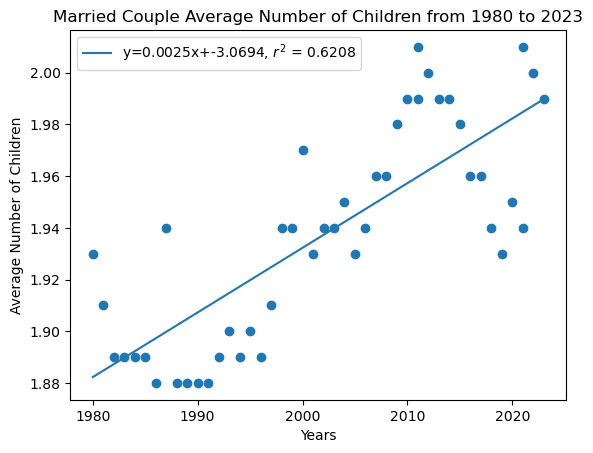

The Linear Regression Line of Fit is given by y=0.0025x+-3.0694, r^2 = 0.6208


In [14]:
years = years = [
1955, 1960, 1965, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2021, 2022, 2023
]
married_couples_with_children_average_child_count = [
2.20, 2.34, 2.44, 2.29, 2.31, 2.22, 2.18, 2.14, 2.09, 2.05, 2.02, 1.98, 1.95, 1.93, 1.91, 1.89, 1.89, 1.89, 1.89, 1.88, 1.94, 1.88, 1.88, 1.88, 1.88, 1.89, 1.90, 1.89, 1.90, 1.89, 1.91, 1.94, 1.94, 1.97, 1.93, 1.94, 1.94, 1.95, 1.93, 1.94, 1.96, 1.96, 1.98, 1.99, 1.99, 2.01, 2.00, 1.99, 1.99, 1.98, 1.96, 1.96, 1.94, 1.93, 1.95, 1.94, 2.01, 2, 1.99
]

LS = least_square(years[13:], married_couples_with_children_average_child_count[13:])
years=np.array(years)
y=LS[0] + LS[1]*years[13:]
# print(len(y))
# print(len(years))
plt.scatter(years[13:],married_couples_with_children_average_child_count[13:])
plt.plot(years[13:],y,label = f"y={np.round(LS[1],4)}x+{np.round(LS[0],4)}, \
$r^{2}$ = {np.round(LS[2]**2,4)}")
# print(LS)
# print(LS[0]**2)
plt.legend()
plt.ylabel("Average Number of Children")
plt.xlabel("Years")
plt.title("Married Couple Average Number of Children from 1980 to 2023")
plt.show()
print(f"The Linear Regression Line of Fit is given by y={np.round(LS[1],4)}x+\
{np.round(LS[0],4)}, r^2 = {np.round(LS[2]**2,4)}")


R-squared values range from 0-10, with 0.8+ values being strong. We have an r^2 value of 0.62, which is not very accurate. This can also be observed in the graph, as the points are spread far apart. However, this r^2 squared value could be skewed lower because of inherent noise in our data set, like how or where the data was collected. 


(c) The intensity of light decreases when it passes through several layers of tinted glass. The intensity of the light drops exponentially due to absorption, following the equation: $$I=I_{0}e^{-kx}$$ Where $I_{0}$ is the initial intensity, and $k$ is the attenuation coefficient.

Similarly, the intensity of a light source drops proportionally to the inverse square law as you move radially away from it (think of walking a distance $d$ away from a lamp): $$I = \frac{A}{d^{2}}$$

The following two data sets represent respectively the amount of layers of tinted glass that light is passing thorugh as well as its measured intensity after each layer, and the distance away from a light source as well as its intensity. Use the linear regression function you previously wrote to fit the data to the given equations. Calculate the $r^{2}$ value for the dataset in its linear transformation. Then, graph the two sets of data in the same figure in side-by-side axis. Label the equation of the curve fits your functions calculated.



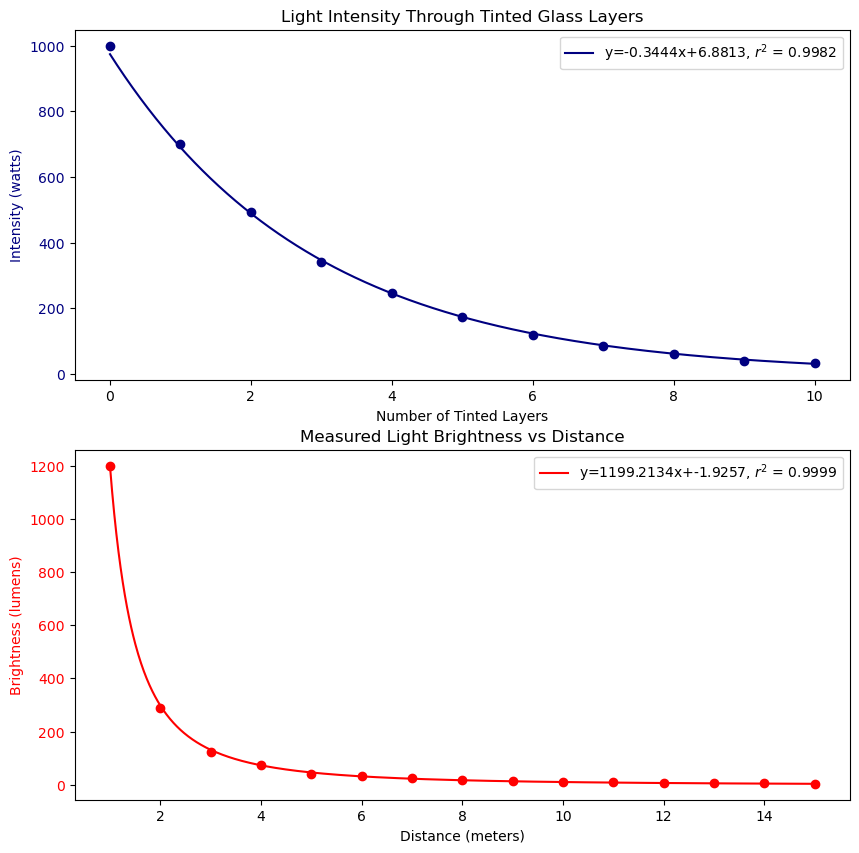

In [15]:
# Given Data:
# Tinted Glass
layers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
intensity = [1000.0, 700.7, 492.6, 339.9, 246.5, 173.5, 118.2, 86.1, 60.7, 40.8, 35.1] # Watts
# Inverse Square
distance = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] # meters
brightness = [1200.0, 290.0, 123.3, 75.0, 42.0, 33.3, 24.5, 18.8, 12.8, 11.0, 9.9, 8.3, 7.1, 6.1, 4.3] # lumens

# Your answer here:


#a0 is intercept, a1 is slope. 

#creating a linspace with more data sets allows for more points
#to fit on our curvefit.
x_layers = np.linspace(0,10,1000)
x_distance = np.linspace(1,15,1000)

#turning into array, allows us to multiply them
layers=np.array(layers)
distance = np.array(distance)


a0_int, a1_int, r_int = least_square(layers,np.log(intensity))
#here, we're iterating over all the 1000 layers
predicted_intensity = np.exp([(a1_int * x + a0_int) for x in x_layers])

a0_bri, a1_bri, r_bri = least_square(1/(distance**2), brightness)
predicted_brightness = [a1_bri*(1/d**2) + a0_bri for d in x_distance] 

fig, (ax1,ax2) = plt.subplots(figsize=(10,10),ncols=1,nrows=2)

ax1.plot(x_layers,predicted_intensity, label = f"y={np.round(a1_int,4)}\
x+{np.round(a0_int,4)}, $r^{2}$ = {np.round(r_int**2,4)}", c="navy")
ax1.scatter(layers,intensity,c="navy")
ax1.tick_params(labelcolor="navy",axis="y")
ax1.set_ylabel("Intensity (watts)", color="navy")
ax1.set_xlabel("Number of Tinted Layers")
ax1.set_title("Light Intensity Through Tinted Glass Layers")
ax1.legend()

ax2.set_ylabel("Brightness (lumens)",c="red")
ax2.tick_params(labelcolor="red",axis="y")
ax2.scatter(distance,brightness,c="red")
ax2.set_title("Measured Light Brightness vs Distance")
ax2.set_xlabel("Distance (meters)")
ax2.plot(x_distance,predicted_brightness,c="red",label = \
f"y={np.round(a1_bri,4)}x+{np.round(a0_bri,4)}, $r^{2}$ = {np.round(r_bri**2,4)}")
ax2.legend()

plt.show()



(d) Utilize the function `scipy.optimize.curve_fit()` to fit the data directly to the given equations without having to linearize it. Reusing the same plot from above, now add the curves solved for using the scipy function and label them in the same way (you can omit the $r^{2}$ values in the label this time). Which curve better represents the data, the one using your linear regression function or the one from the scipy library? Why is that?

Tip: Use the `p0` argument to provide an initial guess for the parameters of your functions when using `curve_fit()`. This is a well-documented function so feel free to search online documentation to learn more about it and its application!


In [16]:
#optimize curve fit uses the estimated trend function of each 
#curve. 

#we also need to feed in our parameters for optimization
def intensity_func(l, i,k):
    return i*np.exp(-k*l)

def brightness_func(d, a0,a1):
    return (a1/(d**2)) + a0

#for p0 we use our guesses from using our previous lin reg func

#for intensity, it was a0_int, a1_int
int_curve_fit = sp.optimize.curve_fit(intensity_func,layers, \
intensity,p0=[a0_int, a1_int])
int_cf_intercept = int_curve_fit[0][0]
int_cf_slope = int_curve_fit[0][1]

#for brightness, it was a0_bri, a1_bri
bri_curve_fit = sp.optimize.curve_fit(brightness_func,distance, \
brightness,p0=[a0_bri, a1_bri])
bri_cf_intercept = bri_curve_fit[0][0]
bri_cf_slope = bri_curve_fit[0][1]

y_int = int_cf_intercept*np.exp(-int_cf_slope*x_layers)
y_bri = (bri_cf_slope / (x_distance**2)) + bri_cf_intercept



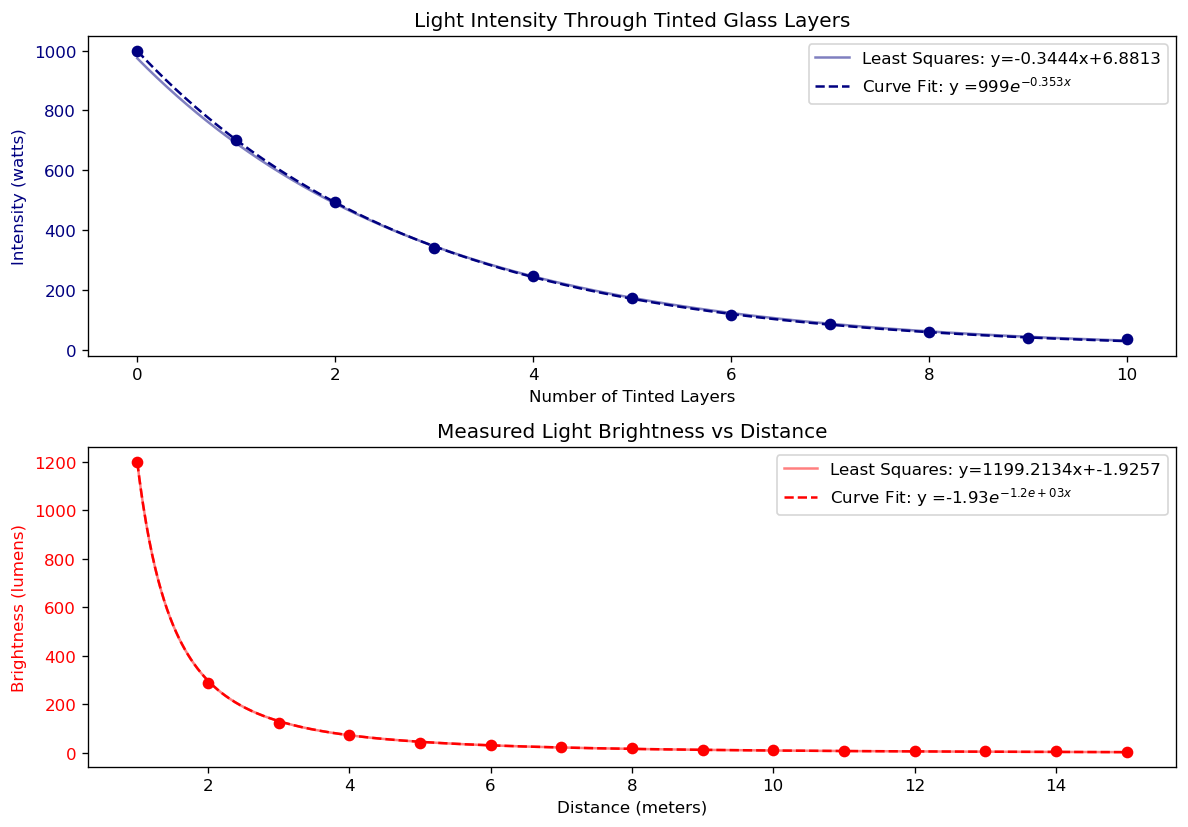

In [17]:
fig, (ax1,ax2) = plt.subplots(figsize=(10,7),nrows=2,ncols=1,dpi=120)


ax1.plot(x_layers,predicted_intensity, label = f"Least Squares: y={np.round(a1_int,4)}\
x+{np.round(a0_int,4)}", c="navy",alpha=0.5)
ax1.scatter(layers,intensity,c="navy")
ax1.set_title("Light Intensity Through Tinted Glass Layers")

ax1.tick_params(labelcolor="navy",axis="y")
ax1.set_ylabel("Intensity (watts)", color="navy")
ax1.set_xlabel("Number of Tinted Layers")
ax1.plot(x_layers,y_int,"--",color="navy",label = f"Curve Fit: y =\
{(int_cf_intercept):.3g}$e^{{-{int_cf_slope:.3g} x}}$")

ax1.legend()

# f"$e^{{-k x}}$"          # k is literal
# f"$e^{{-{int_cf_slope} x}}$"        # k is a variable


ax2.set_ylabel("Brightness (lumens)",c="red")
ax2.tick_params(labelcolor="red",axis="y")
ax2.scatter(distance,brightness,c="red")
ax2.plot(x_distance,predicted_brightness,label = f"Least Squares: \
y={np.round(a1_bri,4)}x+{np.round(a0_bri,4)}",alpha=0.5, color = "red")

ax2.plot(x_distance,y_bri,"--",color="red",label = f"Curve Fit: y =\
{(bri_cf_intercept):.3g}$e^{{-{bri_cf_slope:.3g} x}}$")
ax2.set_xlabel("Distance (meters)")
# ax2.legend(loc="upper left",bbox_to_anchor=(0.48,0.845))
ax2.set_title("Measured Light Brightness vs Distance")
plt.tight_layout()

ax2.legend()
plt.show()





### Problem 3 - Estimating G using Richardson's Extrapolation

You have decided to major in astrophysics and are now studying two celestial bodies. The first body has a mass of $5.48 \times 10^{24}\, \mathrm{kg}$ and the second a mass of $4.95 \times 10^{23}\, \mathrm{kg}$. Using numerical differentiation, you want to take the potential energy data between the two bodies and estimate the gravitational constant $G$. Recall that Newton's Law of Gravitation is given by the equation: $F = G \frac{m_1 m_2}{r^2}$,

where $F$ is the gravitational force, $G$ is the gravitational constant, ${m_1}$ and ${m_2}$ are the masses of the two objects, and $r$ is the distance between the center of masses.

(a) You have collected some data of the Potential Energy ($U$) in terms of the distance ($r$) and stored this under a CSV file (attached to this assignment on canvas under the name: "Problem3_collected_data.csv").

There are two columns in this dataset. The first is titled "Distance (m)" and the second is titled "Measured Potential Energy (J)". You will need to extract the values of these two columns to Numpy arrays using the pandas library. For assistance with reading CSV files and their syntax, please see:

(1) Reading CSV: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

(2) Converting CSV to numpy: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_numpy.html


In [18]:
test = pd.read_csv('/Users/leytonlin/Desktop/MENG/Problem3_collected_data.csv')

#indexes into each "column" of the dataframe and converts to numpy
distance = test["Distance (m)"].to_numpy()
P_E = test["Measured Potential Energy (J)"].to_numpy()


(b) Plot the data. Make your plot visually appealing, with axis labels and a title. What is the distance range over which the data was collected? At what distance increments was the data collected?

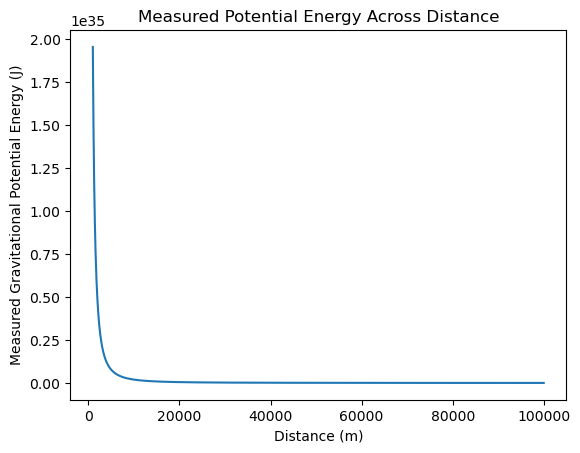

In [19]:
plt.plot(distance,P_E)
plt.xlabel("Distance (m)")
plt.ylabel("Measured Gravitational Potential Energy (J)")
plt.title("Measured Potential Energy Across Distance")
plt
plt.show()

#looking at the csv 99950 1000, intervals of 50



(c) You would like to write a function that calculates the derivative of gravity_potential with respect to distance using the first-order forward finite difference approximation.

The function has been started for you: it takes in min_dist, max_dist, and step_size parameters. This function should return an array of derivatives from min_dist to max_dist.

To check that your function is working properly, compute the derivative across a distance range of [1000, 99900], with a step size of 50 meters.

You have now computed $\frac{dU}{dr}$. Recall that $F = -\frac{dU}{dr}$. With a simple sign switch, you should now have an estimate for the function $F = G \frac{m_1 m_2}{r^2}$. Plot $F$ with respect to $r$.

In [ ]:
def f_double_prime_central_list(y_list, h, GAP, order='low'):
    jump = int(round(h / GAP))
    slopes = []
    limit = 2 * jump if order == 'high' else jump
    for i in range(limit, len(y_list) - limit):
        if order == 'low':
            s = (y_list[i + jump] - 2*y_list[i] + y_list[i - jump]) / (h**2)
        else:
            s = (-y_list[i + 2*jump] + 16*y_list[i + jump] - 30*y_list[i] + 16*y_list[i - jump] - y_list[i - 2*jump]) / (12*h**2)
        slopes.append(s)
    return slopes[-1], slopes

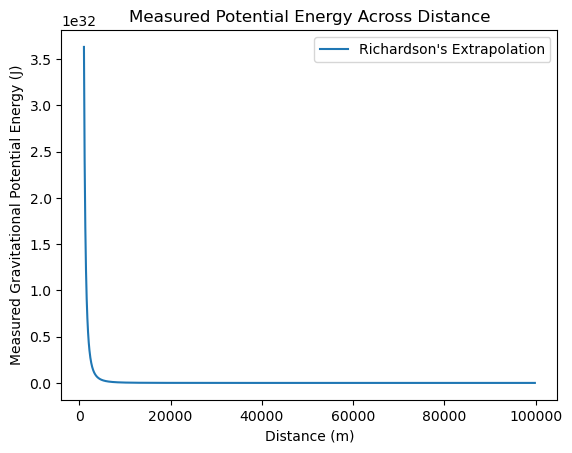

In [20]:
P_E=np.array(P_E)

def forward_finite_differences(min_dist,max_dist,step_size,array):

  derivs=[]

  #jump changes if we jump by 1 or two indices depending on our step size
  jump = int(step_size / 50)
  low_index_bound = np.where(distance==min_dist)
  up_index_bound = np.where(distance==max_dist)
  test = up_index_bound[0][0]
  #print(f"UP_: {up_index_bound}")
  for i in (range(low_index_bound[0][0],test - jump,jump)):
    #print(i)
    #print(array[i])
    d = (array[i+jump] - array[i]) / step_size
    #print(d)
    derivs.append(d)
  return(derivs)
      
#multiplies the values by -1. 
def neg(lists):
  neglist = []
  for i in range(len(lists)):
    neglist.append(-lists[i]) 
  return neglist

def range_func(min_dist,max_dist,step_size):

  return (np.arange(min_dist,max_dist,step_size))

derivs = forward_finite_differences(1000,99900,50,P_E)

dist = (range_func(1000,99900,50))
plt.plot(dist[:-1],neg(derivs),label = "Richardson's Extrapolation")
plt.ylabel("Measured Gravitational Potential Energy (J)")
plt.title("Measured Potential Energy Across Distance")
plt.xlabel("Distance (m)")
plt.legend()
plt.show()
#print(derivs)



(d) Since you are a perfectionist, you would like to use Richardson's extrapolation to provide an even more accurate estimate of your derivative $\frac{dU}{dr}$.

Complete the Richardson's function as indicated below and apply it to your derivative using ${h_1 = }$ 100 m and ${h_2 =}$ 50 m. Use a min value of 1000 m and a max value of 99900 m.

Some tips: The function should use the `forward_finite_differences()` method defined in part (c). Recall that a forward finite difference method has an error of O(${h}$), so you would need to modify the Richardson's formula derived in class (which used the center finite difference as a basis and has an error of O(${h^2}$)).

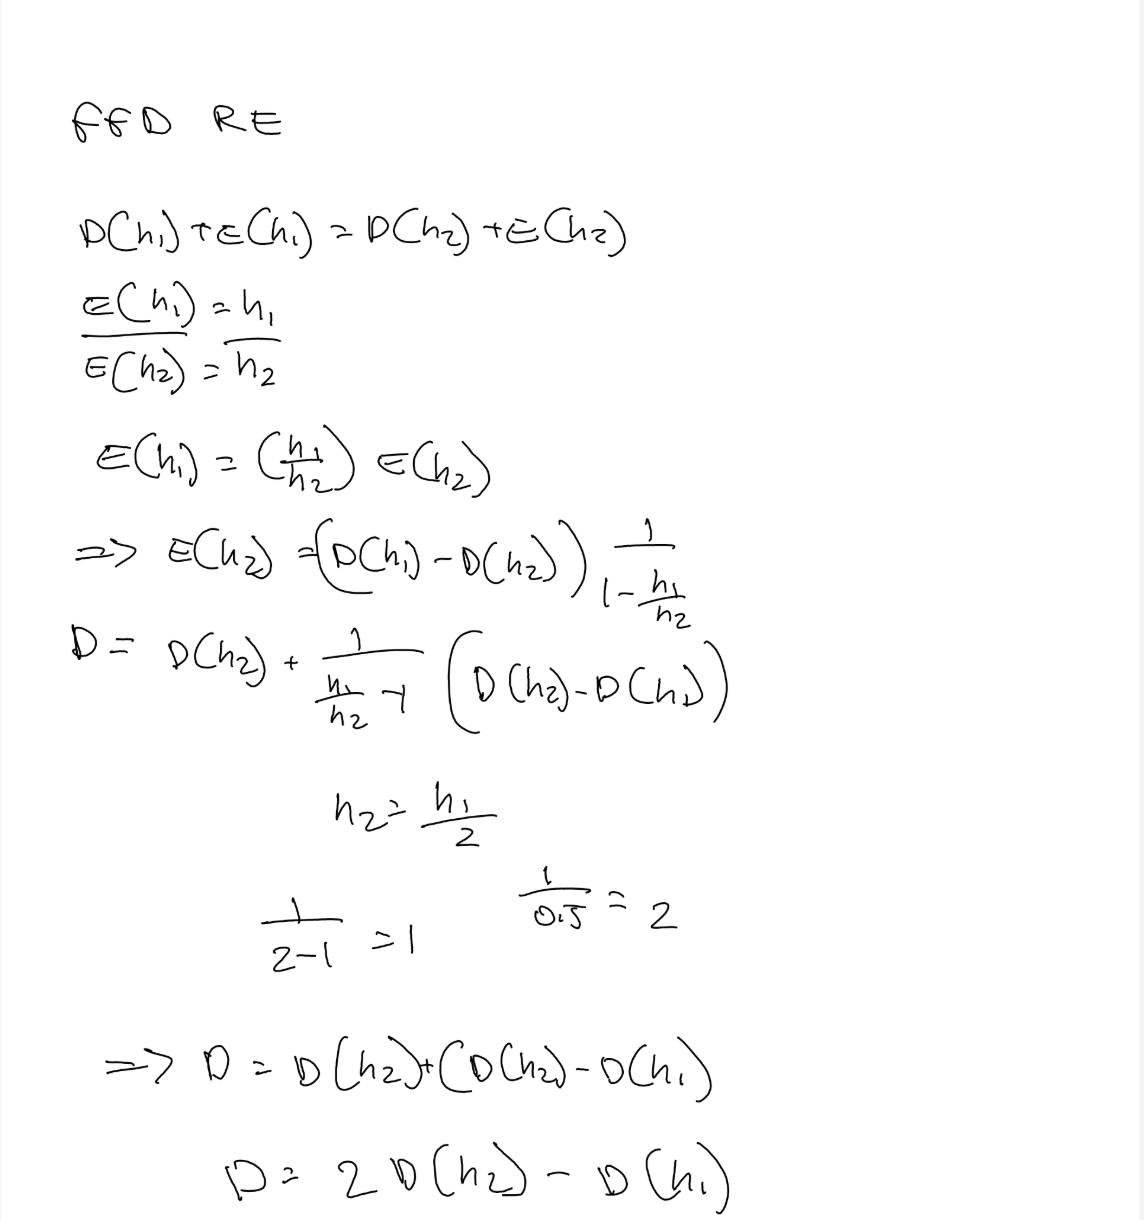

In [21]:
def re(min_dist,max_dist,data, function,step_one,step_half):

    return 2*(np.array(function(min_dist,max_dist,step_half,data)))[:-1:2] - \
np.array(function(min_dist,max_dist,step_one,data))

re_potential = re(1000,99900,P_E,forward_finite_differences,100,50)


(e) Plot $F$ versus $r$ generated via Richardson's Extrapolation and forward finite differences (part c, stepsize = 50 m) on the same plot. Comment on the differences.

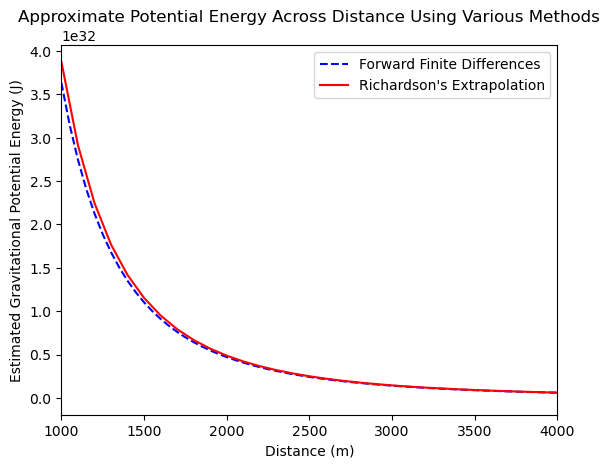

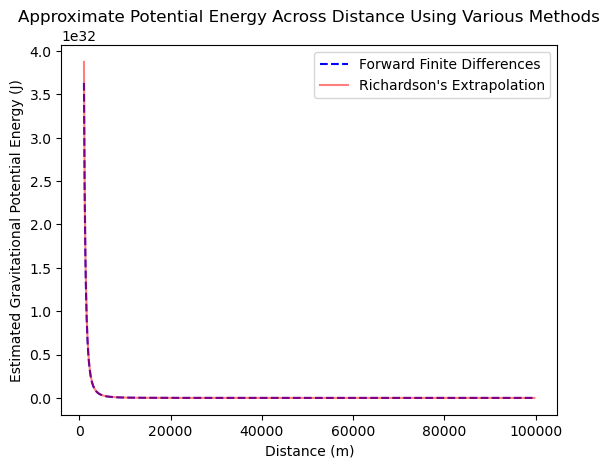

In [22]:
#calling richardson extrap and FFd functions
FFD = neg(forward_finite_differences(1000,99900,50,P_E))
RE = neg(re_potential)
plt.plot(dist[:-1],FFD[:],"--", color="blue", label = "Forward Finite Differences")
plt.plot(dist[:-2:2], RE,color="red", label = "Richardson's Extrapolation")
plt.ylabel("Estimated Gravitational Potential Energy (J)")
plt.title("Approximate Potential Energy Across Distance Using Various Methods")
plt.xlabel("Distance (m)")
plt.xlim(1000,4000)
plt.legend()
plt.show()


plt.plot(dist[:-1],FFD[:],"--", color="blue", label = "Forward Finite Differences")
plt.plot(dist[:-2:2], RE,color="red", label = "Richardson's Extrapolation",alpha=0.5)
plt.ylabel("Estimated Gravitational Potential Energy (J)")
plt.title("Approximate Potential Energy Across Distance Using Various Methods")
plt.xlabel("Distance (m)")
plt.legend()
plt.show()


(f) Using the arrays collected from the Richardson's Extrapolation in part (d), perform curve fitting using the scipy `curve_fit` function, while treating $G$ as a free parameter that you need to optimize.  For full documentation, see here:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html. Hint: you will need to define a "model" function.

Compare the extracted value of $G$ to the true value of the gravitational constant:  ${6.67430\times10^{-11}}$$\frac{\mathrm{N\,m^2}}{\mathrm{kg^2}}$


In [23]:
from scipy.optimize import curve_fit

m1=5.48e24
m2 = 4.95e23

#defines our force function
def forcey(r,G):
    return G*((m1*m2) / (r**2))

#we input our distance values, 
#and our richardson extrapolation values for force
G_constant = curve_fit(forcey, dist[:-2:2], RE)
#this should give us optimized paramter G

print(f"The extracted value of G is {G_constant[0][0]:.6g} Nm^2/kg^2, which is\
 the one order off from the true gravitational \
constant 6.67430e-11 Nm^2/kg^2")


The extracted value of G is 1.1257e-10 Nm^2/kg^2, which is the one order off from the true gravitational constant 6.67430e-11 Nm^2/kg^2


### Problem 4: Lunchtime Experiments

Last week, I brought a loaf of bread to the ERC for lunch each day of the week. I ate half of it, but grew bored of it and forgot about it. Over time, the bread began to grow mold. A group of undergraduates observed this, and rather than notifying me, decided to characterize the growth of microorganisms in the bread over time.

The data is provided below. It is organized by (time, count) pairs. For example, an entry (1.2, 1.7) indicates that at 1.2 hours, 1.7 thousand bacteria were observed.

In [24]:
data = [(1.2, 1.7), (19.6, 1.7), (28.2, 3.6), (40.4, 11.2), (50.2, 22.2), (60.0, 44.7), (13.5, 0.16), (25.7, 1.2), (34.2, 5.2), \
          (44.1, 9.9), (55.1, 31.3), (58.8, 39.9), (4.9, 2.5), (11.0, 2.7), (26.9, 4.7), (36.7, 4.7), (47.8, 15.8), (53.9, 28.8), \
          (2.4, 0.3), (18.4, 1.6), (29.4, 3.2), (38.0, 9.0), (42.9, 15.7), (57.6, 40.0), (6.1, 1.2), (24.5, 5.1), (31.9, 5.3), \
          (39.2, 6.7), (45.3, 16.8), (52.7, 25.4), (8.6, 2.5), (22.0, 6.7), (33.1, 7.2), (41.6, 11.8), (51.4, 23.1), (56.3, 36.3)]

(a)  Create a publication-quality scatterplot of the data for bacteria count versus time.

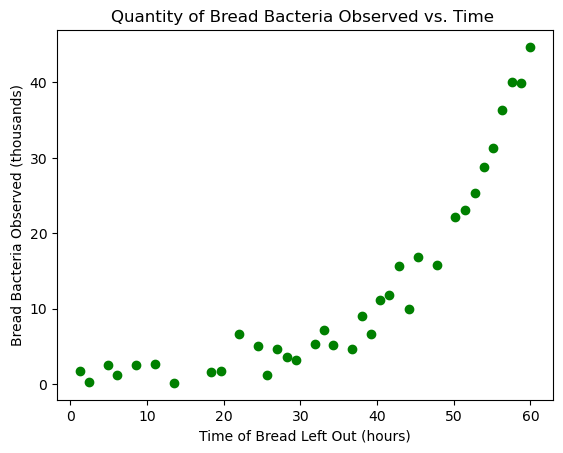

In [25]:
bacteria = []
time = []

#creataing our own lists of the bacteria and time values
for i in range(len(data)):
    bacteria.append(data[i][1])
    time.append(data[i][0])

#scatter plot!
plt.scatter(time,bacteria,c="green")
plt.xlabel("Time of Bread Left Out (hours)")
plt.ylabel("Bread Bacteria Observed (thousands)")
plt.title("Quantity of Bread Bacteria Observed vs. Time ")
plt.show()

(b)  The undergraduates anticipate that the bacteria count can be modeled using an exponential function. Find the parameters of the exponential model using a  linear regression.

In [26]:

#curve looks like an exponential, such that y=e^x
#take natural log of both sides, ln(y)=x
#use lin regress formula
lin_reg= sp.stats.linregress(time,np.log(bacteria))
print(f"Slope of the exponential function: {lin_reg[0]:.5f} bacteria/hr, \
intercept of the exponential function: {lin_reg[1]:.5f} bacteria.")

Slope of the exponential function: 0.06906 bacteria/hr, intercept of the exponential function: -0.47509 bacteria.


(c)  Compare the linearly regressed model expression to the results from scipy's `curve_fit` function.  Plot the original data along with the fitting of both exponential models (i.e., from the linearized regression and `curve_fit`). Print out and compare fitting parameters. Discuss.

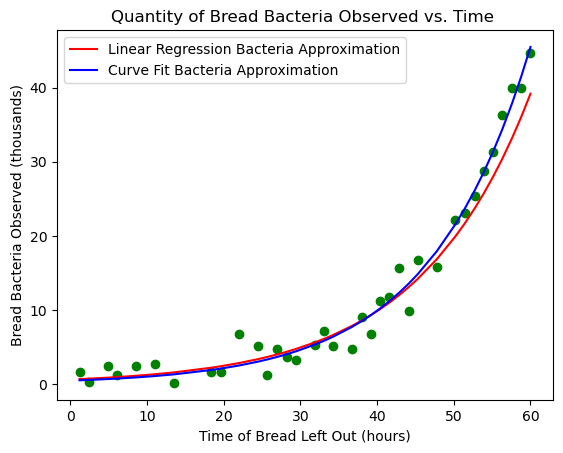

Curve Fit Parameters: Slope = 0.0762 bacteria/hr, Intercept = 0.469 bacteria
Linear Regression Parameters: Slope = 0.0691 bacteria/hr, Intercept = -0.475 bacteria


In [27]:
#convert list to array
time=np.array(time)

#assigns the slopes and intercept from lin_reg
slope = lin_reg[0]
intercept = lin_reg[1]


#we need to sort time, our current list isn't in numerical order
sorted_time = sorted(time)
sorted_time = np.array(sorted_time)

yap = slope*time + intercept
#we now need to plot the curve y using slope and intercept values
#we took log of both sides, so ln(y) = ln(ae^(bx))
#our equation is ln(y) = ln(a)+bx, a = intercept, b = slope
#raise e to the power of both sides
#y = e^(a+bx), we have bacteria in terms of x and parameters
#bacteria = exp(intercept + slope * time)

#predicted_bacteria = intercept*np.exp(slope * sorted_time )

predicted_bacteria = np.exp(slope * sorted_time + intercept)

#we know want to use curve_fit
#curve fit uses a function of the estimated guess
def bacteria_func(time, a,b):
    return a*np.exp(time*b)

#running the curve fit function
#function diverges unless I provide a p0 guess, which is 
#taken from the lin_regression formula

curvefit = curve_fit(bacteria_func,time,bacteria, \
p0 = (np.exp(intercept), slope))

#curvefit[0] indexes into the popt
#curvefit[0][0] indexes into a, the intercept
#curvefit[0][0] indexes into b, the slope

#setting y = ae^(xb)
curve_fit_y = curvefit[0][0]*np.exp(sorted_time*curvefit[0][1])

#plotting!
plt.scatter(time,bacteria,color="green")
plt.plot(sorted_time, predicted_bacteria, color='red', \
label="Linear Regression Bacteria Approximation")
plt.plot(sorted_time,curve_fit_y,\
label = "Curve Fit Bacteria Approximation", color = "b")

plt.ylabel("Bread Bacteria Observed (thousands)")
plt.title("Quantity of Bread Bacteria Observed vs. Time ")
plt.xlabel("Time of Bread Left Out (hours)")

plt.legend()
plt.show()

print(f"Curve Fit Parameters: Slope = {curvefit[0][1]:.3g} bacteria/hr, \
Intercept = {curvefit[0][0]:.3g} bacteria")
print(f"Linear Regression Parameters: Slope = \
{slope:.3g} bacteria/hr, Intercept = {lin_reg[1]:.3g} bacteria")


(d)  Provide scatterplots of the residuals of the model fits to the empirical data plotted versus time, with separate plots in the same figure for the linear regression and the scipy `curve_fit` function. Comment on these plots.

Explain how these two approaches fit the empirical data to the exponential model (i.e., what is the numeric computation being performed) and why are the outcomes are different? Which fit is better? Justify your conclusion.

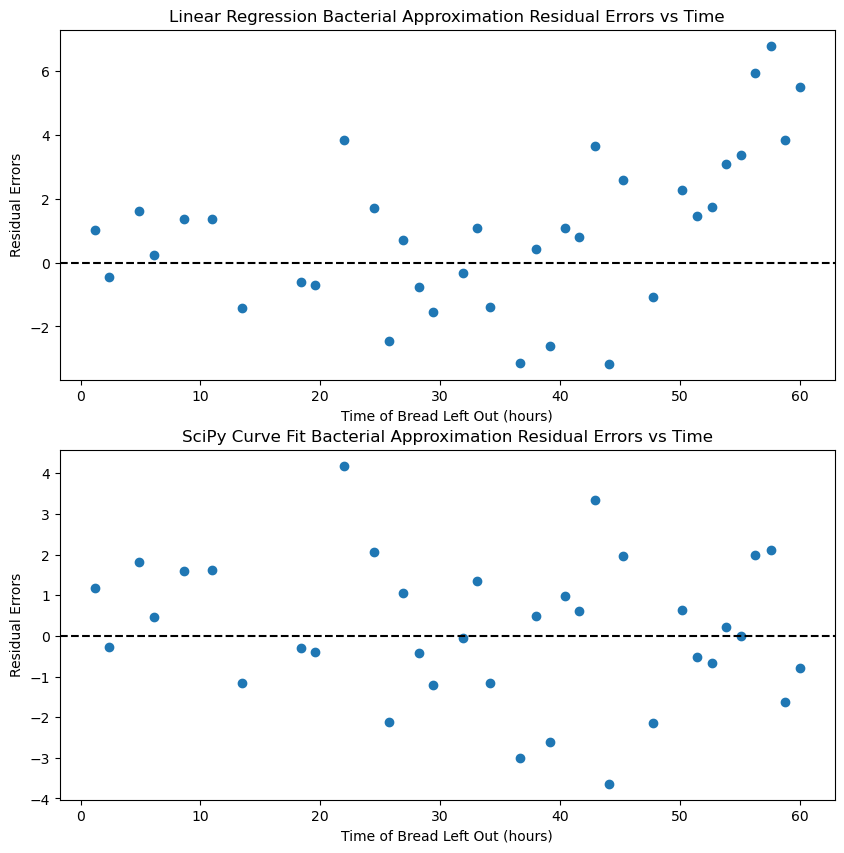

In [28]:
plt.figure(figsize=(10,10))

predicted_bacteria_unsorted = np.exp(slope * time + intercept)
curve_fit_y_unsorted = curvefit[0][0]*np.exp(time*curvefit[0][1])

#calculating residuals, which is true - appx
resid_curve = bacteria - curve_fit_y_unsorted
resid_lin = bacteria - predicted_bacteria_unsorted

#linear regression
plt.subplot(211)
plt.scatter(time, resid_lin,label = "lin")
#plt.plot(sorted_time, predicted_bacteria, color='red', \label="lin regress")
plt.axhline(y=0,c="black",linestyle="--")
plt.xlabel("Time of Bread Left Out (hours)")
plt.ylabel("Residual Errors")
plt.title("Linear Regression Bacterial Approximation Residual Errors vs Time")
#curve fit
plt.subplot(212)
#plt.scatter(time, resid_lin,label = "lin")
#plt.plot(sorted_time,curve_fit_y,label = "curve fot", color = "b")
plt.axhline(y=0,c="black",linestyle="--")
plt.scatter(time,resid_curve,label="curve")
plt.xlabel("Time of Bread Left Out (hours)")
plt.ylabel("Residual Errors")
plt.title("SciPy Curve Fit Bacterial Approximation Residual Errors vs Time")
plt.show()



Looking at the residuals plot, the SciPy Curve Fit has a more even spread of residuals (y limits from -4,4) then the linear regression fit (-2,6), which indicates that the curve fit is a better model for bacteria growth. A good fit is one where the residuals are evenly distributed above and below the horizontal y=0 line, relatively consistent residual values, and no trends (which would indicate our model underperfoming at a specific point). Using these metrics, it seems like the scipy curve fit is a better model. We can also observe this in the graph from 4C, where it looks like the curve fit model follows the bacteria growth trend "better" than the linear regression one. 

This is due to the inherent differences in each model. Linear regression takes a "curve" and converts it to a linear function y=mx+b, so it's inherently stronger at modeling more linear functions. Curve fit is not constrained by this and can model linear and non linear functions. It may struggle more in this case because the model is exponential, not linear, so it's slope and intercept conditions are more limited. With SciPy Curve Fit, we input a "guess" of the model (exponential in this case) and it uses this guess to find a curve. This aligns more with the original bacteria curve, which is maybe why the SciPy Curve Fit is better and leads to a better residuals outcome. 

(e) Now generate a histogram of the residuals.  Bin the residuals into 10 bins. Comment on this plot. Find the mean and standard deviation of the residuals. Why is the mean residual not 0?

Calculated Standard Deviation and Mean from Linear Regression: mean = 0.999, std = 2.43
Calculated Standard Deviation and Mean from Curve Fit: mean = 0.154, std = 1.72


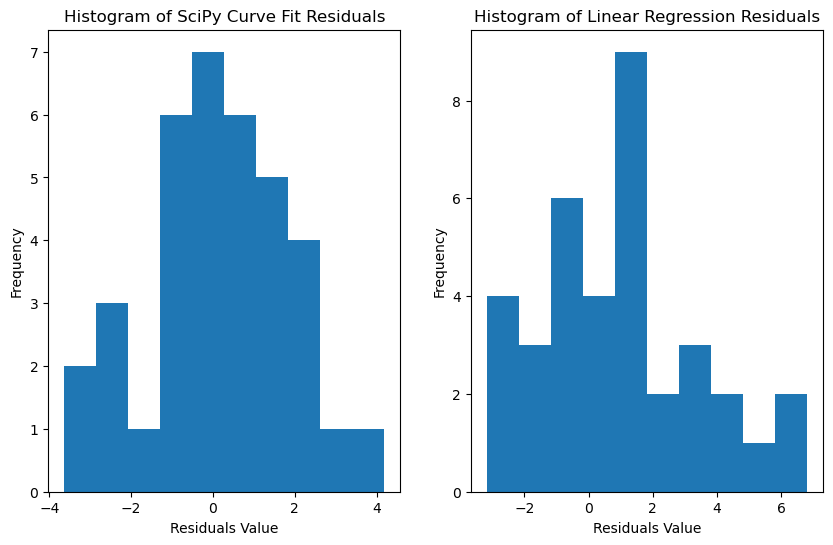

In [29]:
plt.figure(figsize=(10,6))
plt.subplot(121)
plt.ylabel("Frequency")
plt.xlabel("Residuals Value")
plt.title("Histogram of SciPy Curve Fit Residuals")
plt.hist(resid_curve,10)

plt.subplot(122)
plt.hist(resid_lin,bins=10)
plt.ylabel("Frequency")
plt.xlabel("Residuals Value")
plt.title("Histogram of Linear Regression Residuals")
plt.show

print(f"Calculated Standard Deviation and Mean from Linear Regression: \
mean = {np.mean(resid_lin):.3g}, std = {np.std(resid_lin):.3g}")
print(f"Calculated Standard Deviation and Mean from Curve Fit: mean \
= {np.mean(resid_curve):.3g}, std = {np.std(resid_curve):.3g}")


Residuals should have a mean of zero in linear form. This isn't observed in either residuals plot. This is because for the Linear Regression, the error is not inherently removed. In the linear regression, the error term is here: ln(y) = mx+b + error. Here, error is minimized and the mean should be zero. However, since we're plotting y = e^(mx+b+error), the mean of the exponential error term may no longer be zero. For the SciPy Curve Fit, this is because it uses least squares regression, which means it minimizes the square of the regression, not just the regression. This means the averages will be different, and hence why the mean is not equal to 0. 

Looking at the residual histograms, we see a somewhat normally distributed curve, with a more even range for the SciPy Curve Fit than the linear regression ones. It feels like the linear regression one skews more negative, whereas the SciPy Curve Fit skews more positive. 

(f)  Oops! I ate a slice of the bread at the 40 hour mark. I will fall sick if I consume more than 10 thousand bacteria. Supposing that the residuals are normally distributed, use your result from part (e) to estimate the probability that I fall sick. Feel free to use this applet.
https://homepage.divms.uiowa.edu/~mbognar/applets/normal.html

In [30]:
curve_fit_y_unsorted = curvefit[0][0]*np.exp(40*curvefit[0][1])

print(f"The predicted quantity of bacteria at \
40 hours is {curve_fit_y_unsorted*1000:.5g}.")



The predicted quantity of bacteria at 40 hours is 9904.8.


To find the probability of getting sick, we need to look at the *predicted *bacteria quantity at 40 hour mark and see how close it is to 10,000. Because there's some residual error, we want to calculate the odds that our (predicted_bacteria_quantity) is actually true, which is based on the residuals. 

Using our "better" model (curve fit) with a t time input of 40, we predict the bacteria population to be 9,900 bacteria, which is very close to 10,000. Now, using our mean and standard deviation for the bacteria model prediction, we can use the applet to calculate the probability that our prediction deviates by 0.1 (as this is how much our current prediction deviates from the 10,000 minimum bacteria mark). We use a mean of 0.1542273707047914 and standard deviation of 1.7187756014217745, x=0.1.

Using these metrics, there is a 51.258% chance that you will get sick from eating the sandwich :(. 